In [307]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import cellspec as spc
import umap
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

%matplotlib inline

In [2]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]
extended_colors = [
    '#2E2A3A',
    '#FF8DAF', '#FF1B5E',
    '#FFEDA0', '#FFDB57',
    '#A4C8FE', '#438CFD',
    '#FFCF80', '#FF8C00',
    '#C4F9AE', '#80F15E',
    '#A0FFFF', '#03FFFF',
    '#A99FD4', '#5941A9',
    '#F4BFFE', '#E980FC',
    '#E8E4F0', '#C4BDD6',
    '#E8C89A', '#C17F3E'
]

In [3]:
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [4]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    "axes.linewidth": 2.5,
    # Tick marks
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# Data loading and setup

In [5]:
adata = spc.pp.load_vcf('../results/worm6_final/joint_variants/joint_variants.vcf.gz')

Loading VCF: 964005 sites [13:29, 1191.11 sites/s]
/loc/scratch/64032735/ipykernel_16650/1603402173.py:1: UserWarning: Found 10 duplicate variant records in VCF (same CHROM-POS-REF>ALT). Kept first occurrence of each. Consider deduplicating your VCF with: bcftools norm -d exact input.vcf.gz -Oz -o output.vcf.gz
  adata = spc.pp.load_vcf('../results/worm6_final/joint_variants/joint_variants.vcf.gz')


Building matrices for 963995 sites × 2404 samples...
Done! Loaded 963995 sites × 2404 samples


In [6]:
data = pd.read_csv('/fh/working/srivatsan_s/Dustin/worm6-dubnova-100k-align/pooled_sc_qc_metrics.csv', index_col='barcode')
adata.obs = data.loc[adata.obs_names]

In [7]:
## Filter out non snps
spc.pp.filter_to_snps(adata, inplace=True)

In [8]:
spc.pp.annotate_contexts(adata, fasta_path='/shared/biodata/reference/iGenomes/Caenorhabditis_elegans/Ensembl/WBcel235/Sequence/WholeGenomeFasta/genome.fa')
adata.var

Annotating trinuc contexts: 100%|██████████| 963336/963336 [00:09<00:00, 97027.92 sites/s] 


,chrom,pos,anc,der,trinuc_type
I-583-T>G,I,583,ATA,AGA,ATA>AGA
I-584-A>C,I,584,TAC,TCC,GTA>GGA
I-607-T>G,I,607,ATA,AGA,ATA>AGA
I-608-A>C,I,608,TAC,TCC,GTA>GGA
I-626-A>C,I,626,GAC,GCC,GTC>GGC
...,...,...,...,...,...
X-17717242-G>T,X,17717242,TGA,TTA,TCA>TAA
X-17717266-C>A,X,17717266,TCA,TAA,TCA>TAA
X-17717292-G>T,X,17717292,TGT,TTT,ACA>AAA
X-17717380-C>A,X,17717380,ACT,AAT,ACT>AAT


In [9]:
adata.write_h5ad('../results/worm6_final/joint_variants/joint_variants.h5ad')

In [5]:
adata = ad.read_h5ad('../results/worm6_final/joint_variants/joint_variants.h5ad')
adata

AnnData object with n_obs × n_vars = 2404 × 963336
    obs: 'sample', 'total_reads', 'aligned_reads', 'pct_aligned', 'mean_read_length', 'mean_insert_size', 'read_duplicates', 'pct_duplicates', 'exonic_reads', 'exonic_enrichment', 'splice_reads', 'pct_1x', 'pct_5x', 'pct_10x', 'mean_coverage', 'median_coverage', 'gini', 'unique_aligned_reads', 'bam_path'
    var: 'chrom', 'pos', 'anc', 'der', 'trinuc_type'
    uns: 'n_cells', 'n_variants', 'vcf_source'
    layers: 'AD', 'DP'

# QC

### Depth in bulk

In [6]:
adata.var['bulk_dp'] = np.ravel(adata.layers['DP'].sum(axis=0))

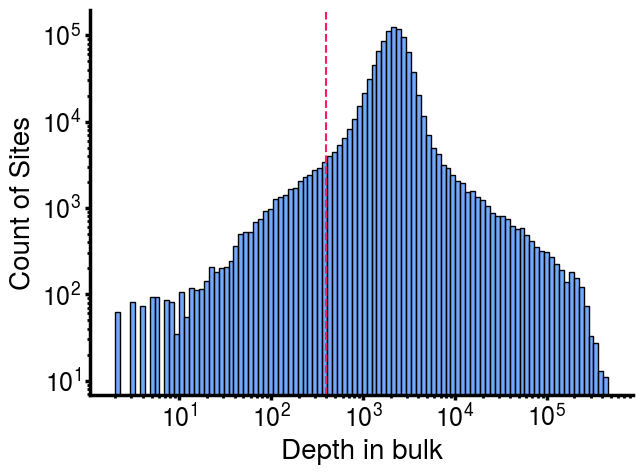

In [7]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.var, x='bulk_dp', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             log_scale=True,
             bins=100
            )

plt.axvline(x=400, color=colors[0], linestyle='--', linewidth=1.5)

ax.set_yscale('log')
plt.xlabel("Depth in bulk", fontsize=20)
plt.ylabel("Count of Sites", fontsize=20)
ax.tick_params(labelsize=18)

In [8]:
np.histogram(adata.var['bulk_dp'])

(array([959090,   2492,    868,    381,    288,    127,     42,     24,
            17,      7]),
 array([2.0000000e+00, 4.6791801e+04, 9.3581602e+04, 1.4037141e+05,
        1.8716120e+05, 2.3395100e+05, 2.8074081e+05, 3.2753059e+05,
        3.7432041e+05, 4.2111022e+05, 4.6790000e+05], dtype=float32))

In [9]:
adata = adata[:,(adata.var['bulk_dp']>400)].copy()

### Allele Frequency Spectrum in Bulk

In [10]:
spc.tl.compute_bulk_vaf(adata,
                        # target_dp=int(adata.var['bulk_dp'].median())
                        target_dp=1000
                       )

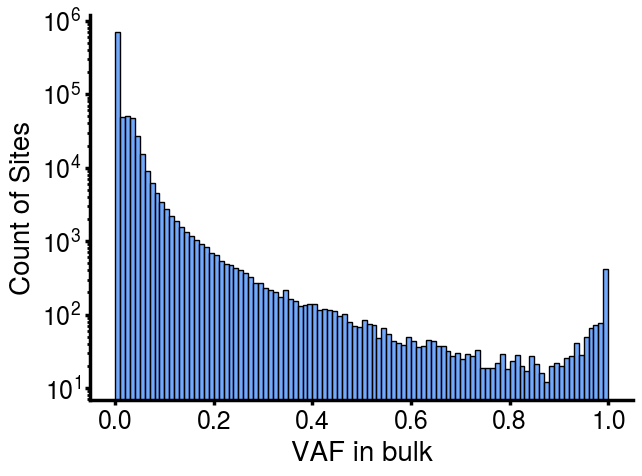

In [11]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.var, x='bulk_vaf', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             # log_scale=True,
             bins=100
            )
ax.set_yscale('log')
plt.xlabel("VAF in bulk", fontsize=20)
plt.ylabel("Count of Sites", fontsize=20)
ax.tick_params(labelsize=18)

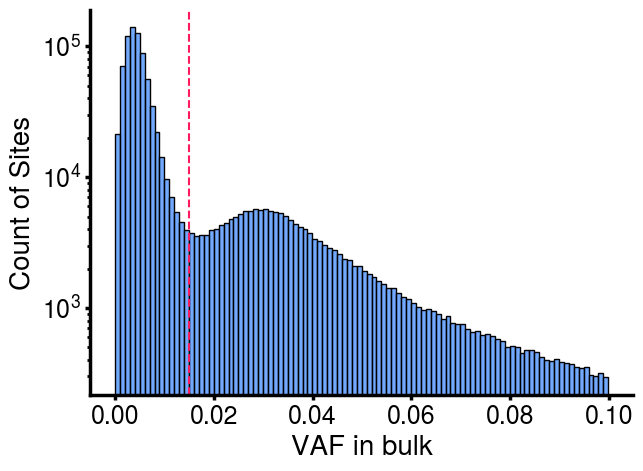

In [12]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.var[adata.var['bulk_vaf']<0.1], x='bulk_vaf', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             # log_scale=True,
             bins=100
            )
plt.axvline(x=0.015, color=colors[0], linestyle='--', linewidth=1.5)
# plt.axvline(x=0.0375, color=colors[0], label='', linestyle='--', linewidth=1.5)
# plt.axvline(x=0.05, color=colors[0], label='', linestyle='--', linewidth=1.5)

ax.set_yscale('log')
plt.xlabel("VAF in bulk", fontsize=20)
plt.ylabel("Count of Sites", fontsize=20)
ax.tick_params(labelsize=18)

### Single Cell metrics

In [13]:
adata.obs['LF_count'] = (adata[:,(adata.var['bulk_vaf']<0.015)].layers['AD']>1).toarray().sum(axis=1)

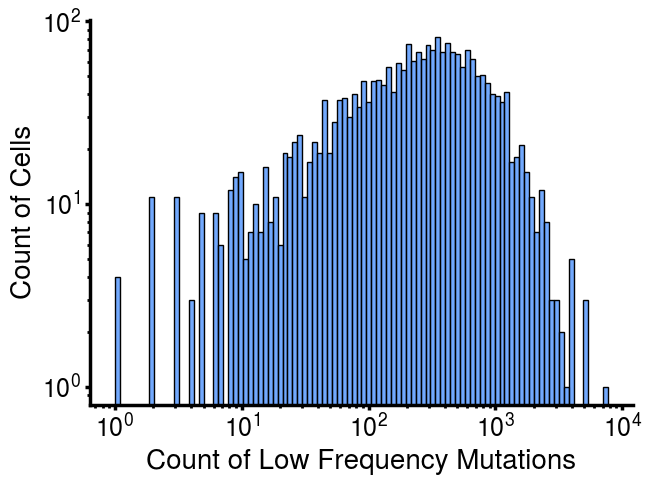

In [14]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.obs, x='LF_count', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             log_scale=True,
             bins=100
            )
ax.set_yscale('log')
plt.xlabel("Count of Low Frequency Mutations", fontsize=20)
plt.ylabel("Count of Cells", fontsize=20)
ax.tick_params(labelsize=18)

In [15]:
adata.obs['HF_count'] = (adata[:,(adata.var['bulk_vaf']>0.015)].layers['AD']>1).toarray().sum(axis=1)

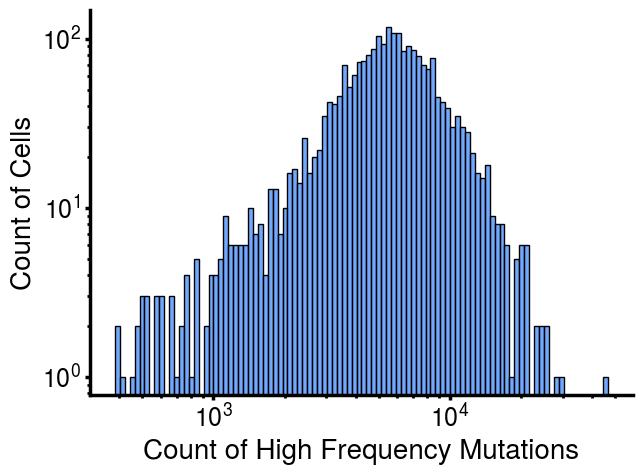

In [16]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.obs, x='HF_count', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             log_scale=True,
             bins=100
            )
ax.set_yscale('log')
plt.xlabel("Count of High Frequency Mutations", fontsize=20)
plt.ylabel("Count of Cells", fontsize=20)
ax.tick_params(labelsize=18)

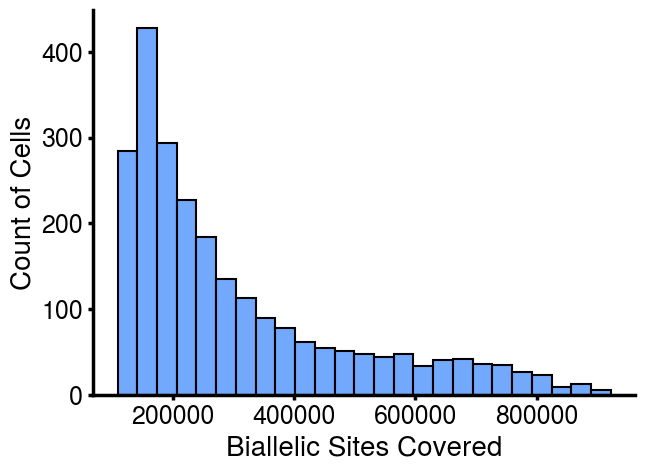

In [17]:
adata.obs['sites_covered'] = (adata.layers['DP']>0).toarray().sum(axis=1)
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.obs, x='sites_covered', 
             alpha=0.75,
             color = colors[2],
             linewidth=1.5,
             ax=ax,
             # log_scale=True,
             bins=25
            )
# ax.set_yscale('log')
plt.xlabel("Biallelic Sites Covered", fontsize=20)
plt.ylabel("Count of Cells", fontsize=20)
ax.tick_params(labelsize=18)

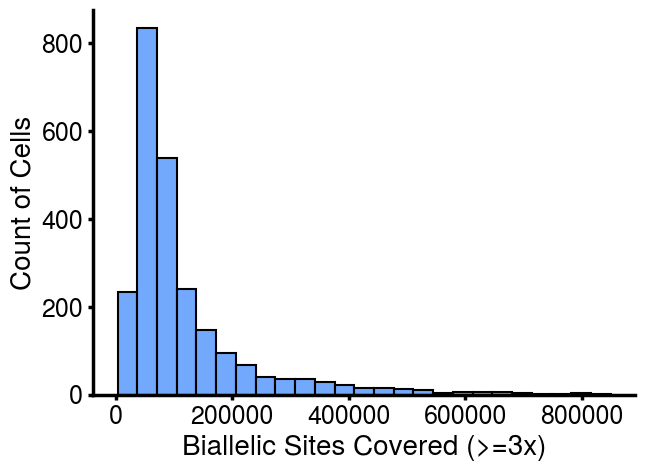

In [18]:
adata.obs['sites_covered_3x'] = (adata.layers['DP']>2).toarray().sum(axis=1)
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.obs, x='sites_covered_3x', 
             alpha=0.75,
             color = colors[2],
             linewidth=1.5,
             ax=ax,
             # log_scale=True,
             bins=25
            )
# ax.set_yscale('log')
plt.xlabel("Biallelic Sites Covered (>=3x)", fontsize=20)
plt.ylabel("Count of Cells", fontsize=20)
ax.tick_params(labelsize=18)

# Haplotype Assignment

In [19]:
AD = adata.layers["AD"].toarray()
DP = adata.layers["DP"].toarray()
AF = adata.var['bulk_vaf']

In [20]:
# =============================================================================
# Helpers
# =============================================================================
def build_matrix(vaf_lo, vaf_hi):
    """Centred cells x variants matrix over the VAF window, plus the indices.

    Uncovered entries are imputed at the per-variant mean, which after centring
    is exactly 0, so they drop out of the factorization.
    """
    inf_idx = np.flatnonzero((AF > vaf_lo) & (AF < vaf_hi))
    ad_i = AD[:, inf_idx].astype(np.float32)
    dp_i = DP[:, inf_idx].astype(np.float32)
    m_i = dp_i >= MIN_DP_VAR
    M_i = m_i.astype(np.float32)
    with np.errstate(invalid="ignore", divide="ignore"):
        f_i = np.where(m_i, ad_i / np.maximum(dp_i, 1), np.nan)
    colmean = np.nansum(np.where(m_i, f_i, 0), 0) / np.maximum(M_i.sum(0), 1)
    X = np.where(m_i, f_i - colmean, 0.0).astype(np.float32)
    stats = dict(n_var=len(inf_idx),
                 sites_per_cell=float(np.median(M_i.sum(1))),
                 cells_per_var=float(np.median(M_i.sum(0))))
    del ad_i, dp_i, f_i, M_i, m_i
    return X, inf_idx, stats


def _norm(V):
    return V / np.maximum(np.linalg.norm(V, axis=1, keepdims=True), 1e-9)


def _modules(Xm, ncomp, K, seed=0):
    """SVD -> L2-normalised variant loadings -> KMeans. Returns labels, dists."""
    V = TruncatedSVD(n_components=ncomp, random_state=seed).fit(Xm).components_.T
    Vn = _norm(V)
    km = KMeans(K, n_init=10, random_state=0).fit(Vn)
    d = np.linalg.norm(Vn - km.cluster_centers_[km.labels_], axis=1)
    return km.labels_ + 1, d


def _score(cidx, lab):
    """Cell x module weights: depth-weighted mean VAF over each module."""
    use = np.unique(lab)
    S = np.zeros((AD.shape[0], len(use)))
    for j, k in enumerate(use):
        c = cidx[lab == k]
        a = AD[:, c].astype(np.float64)
        dd = DP[:, c].astype(np.float64)
        ok = dd >= MIN_DP_VAR
        S[:, j] = (a * ok).sum(1) / np.maximum((dd * ok).sum(1), 1)
    W = S / np.maximum(S.sum(1, keepdims=True), 1e-9)
    return W, use[S.argmax(1)]

## Parameter sweep

### `0.018<VAF<0.06`

In [34]:
# Parameters
MIN_DP_VAR   = 1     # depth for a cell to "observe" a variant
VAF_LO   = 0.018     # drop low frequency somatic variants
VAF_HI   = 0.06      # drop founder / strain-background (carried by all or many worms)

# setup
inf_mask = (AF > VAF_LO) & (AF < VAF_HI)
inf_idx  = np.flatnonzero(inf_mask)
print(f"informative variants: {len(inf_idx)} of {AD.shape[1]}")

ad_i = AD[:, inf_idx].astype(np.float32)
dp_i = DP[:, inf_idx].astype(np.float32)
m_i  = dp_i >= MIN_DP_VAR
M_i  = m_i.astype(np.float32)
 
with np.errstate(invalid="ignore", divide="ignore"):
    f_i = np.where(m_i, ad_i / np.maximum(dp_i, 1), np.nan)
colmean = np.nansum(np.where(m_i, f_i, 0), 0) / np.maximum(M_i.sum(0), 1)
X = np.where(m_i, f_i - colmean, 0.0).astype(np.float32)   # cells x variants
A = ((ad_i >= 1) & m_i).astype(np.float32)                 # presence, for NMF
 
print(f"matrix {X.shape} | sites covered per cell: median {M_i.sum(1).mean():.0f}")
print(f"cells covering each variant: median {np.median(M_i.sum(0)):.0f}")

full panel (2404, 143970) | core size 12000 | grid 5x5
  ncomp= 12 K= 14 | excess purity 0.608 | cell stab 0.822 | size CV 0.64
  ncomp= 12 K= 16 | excess purity 0.518 | cell stab 0.796 | size CV 0.61
  ncomp= 12 K= 18 | excess purity 0.432 | cell stab 0.818 | size CV 0.51
  ncomp= 12 K= 20 | excess purity 0.376 | cell stab 0.731 | size CV 0.54
  ncomp= 12 K= 22 | excess purity 0.391 | cell stab 0.638 | size CV 0.39
  ncomp= 16 K= 14 | excess purity 0.616 | cell stab 0.706 | size CV 0.56
  ncomp= 16 K= 16 | excess purity 0.688 | cell stab 0.749 | size CV 0.30
  ncomp= 16 K= 18 | excess purity 0.746 | cell stab 0.906 | size CV 0.32
  ncomp= 16 K= 20 | excess purity 0.769 | cell stab 0.879 | size CV 0.29
  ncomp= 16 K= 22 | excess purity 0.608 | cell stab 0.764 | size CV 0.31
  ncomp= 20 K= 14 | excess purity 0.251 | cell stab 0.407 | size CV 0.48
  ncomp= 20 K= 16 | excess purity 0.241 | cell stab 0.318 | size CV 0.73
  ncomp= 20 K= 18 | excess purity 0.524 | cell stab 0.619 | size CV 0

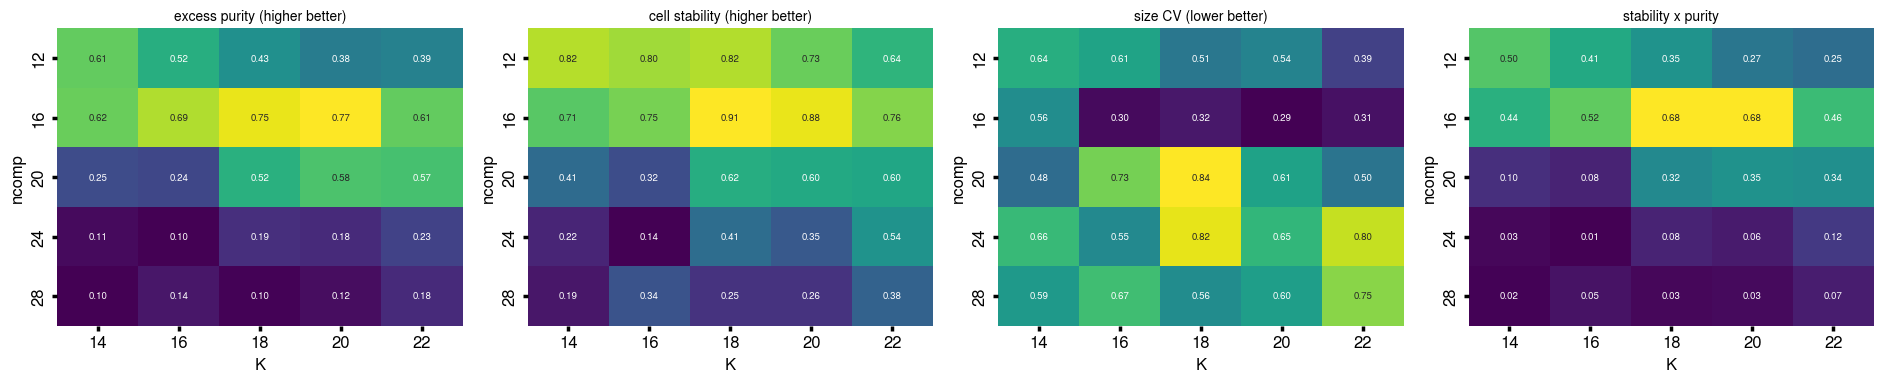


top combinations:
 ncomp  K  excess_purity  raw_purity    med_d  cell_stability  var_stability  size_cv  smallest  combined
    16 20       0.768908    0.780463 0.043107        0.879494       0.954057 0.285524        52  0.676250
    16 18       0.746143    0.760246 0.064809        0.905963       0.939903 0.321753        71  0.675977
    16 16       0.687544    0.707073 0.103920        0.749345       0.877138 0.298691        72  0.515208
    12 14       0.608033    0.636030 0.097660        0.822310       0.787836 0.636054        70  0.499991
    16 22       0.608419    0.626218 0.053561        0.764210       0.917347 0.309617        51  0.464960
    16 14       0.616307    0.643714 0.169807        0.706400       0.751692 0.556717       105  0.435359
    12 16       0.518309    0.548415 0.064792        0.795729       0.857458 0.610626        70  0.412433
    12 18       0.432160    0.463707 0.059559        0.818289       0.872438 0.506872        70  0.353632


In [38]:
# =============================================================================
# SWEEP n_components x K, RESELECTING the core inside the loop.
#   Each (ncomp, K) gets its own core, so no combination inherits a core chosen
#   under different settings. N_CORE is a fixed COUNT, not a distance cut:
#   median distance grows with n_components, so a fixed threshold would give
#   different K values different panel sizes and confound the comparison.
#
#   Runtime note: one SVD on the full panel (reused via slicing, since singular
#   vectors are nested), then one small SVD per grid cell plus N_REP per cell
#   for stability.
# =============================================================================
NCOMP_LIST = [12, 16, 20, 24, 28]
K_LIST     = [14, 16, 18, 20, 22]
N_CORE     = 12000        # variants kept per fit (fixed across the grid)
N_REP      = 3            # random cell halves for stability

maxc = max(max(NCOMP_LIST), max(K_LIST))
rng  = np.random.default_rng(0)
halves = [rng.random(X.shape[0]) < 0.5 for _ in range(N_REP)]

def _norm(V):
    return V / np.maximum(np.linalg.norm(V, axis=1, keepdims=True), 1e-9)

def _modules(Xm, ncomp, K, seed=0):
    V = TruncatedSVD(n_components=ncomp, random_state=seed).fit(Xm).components_.T
    Vn = _norm(V)
    km = KMeans(K, n_init=10, random_state=0).fit(Vn)
    d = np.linalg.norm(Vn - km.cluster_centers_[km.labels_], axis=1)
    return km.labels_ + 1, d

def _score(cidx, lab):
    use = np.unique(lab)
    S = np.zeros((AD.shape[0], len(use)))
    for j, k in enumerate(use):
        c = cidx[lab == k]
        a = AD[:, c].astype(np.float64); dd = DP[:, c].astype(np.float64)
        ok = dd >= MIN_DP_VAR
        S[:, j] = (a * ok).sum(1) / np.maximum((dd * ok).sum(1), 1)
    W = S / np.maximum(S.sum(1, keepdims=True), 1e-9)
    return W, use[S.argmax(1)]

# one SVD on ALL informative variants; sliced per ncomp (vectors are nested)
V_full = TruncatedSVD(n_components=maxc, random_state=0).fit(X).components_.T
print(f"full panel {X.shape} | core size {N_CORE} | grid "
      f"{len(NCOMP_LIST)}x{len(K_LIST)}")

rows = []
for ncomp in NCOMP_LIST:
    Vn0 = _norm(V_full[:, :ncomp])
    for K in K_LIST:
        # 1. provisional modules on the full panel -> pick this cell's core
        km0 = KMeans(K, n_init=10, random_state=0).fit(Vn0)
        d0 = np.linalg.norm(Vn0 - km0.cluster_centers_[km0.labels_], axis=1)
        core = np.sort(np.argsort(d0)[:min(N_CORE, len(d0))])
        Xc, cidx = X[:, core], inf_idx[core]

        # 2. refit on the core, score cells
        lab, d = _modules(Xc, ncomp, K)
        W, donor_k = _score(cidx, lab)
        pur = W.max(1)
        excess = (np.median(pur) - 1/K) / (1 - 1/K)
        sz = np.bincount(donor_k); sz = sz[sz > 0]

        # 3. stability: refit modules on half the CELLS, rescore ALL cells
        cell_ari, var_ari = [], []
        for h in halves:
            lab_r, _ = _modules(Xc[h], ncomp, K, seed=1)
            var_ari.append(adjusted_rand_score(lab, lab_r))
            _, donor_r = _score(cidx, lab_r)
            cell_ari.append(adjusted_rand_score(donor_k, donor_r))

        rows.append(dict(ncomp=ncomp, K=K, excess_purity=excess,
                         raw_purity=np.median(pur), med_d=np.median(d),
                         cell_stability=np.mean(cell_ari),
                         var_stability=np.mean(var_ari),
                         size_cv=sz.std()/sz.mean(), smallest=sz.min()))
        print(f"  ncomp={ncomp:>3} K={K:>3} | excess purity {excess:.3f} | "
              f"cell stab {np.mean(cell_ari):.3f} | size CV {sz.std()/sz.mean():.2f}")

sweep = pd.DataFrame(rows)
sweep["combined"] = sweep.cell_stability * sweep.excess_purity

fig, ax = plt.subplots(1, 4, figsize=(19, 4))
for a, col, ttl in zip(ax, ["excess_purity", "cell_stability", "size_cv", "combined"],
                       ["excess purity (higher better)", "cell stability (higher better)",
                        "size CV (lower better)", "stability x purity"]):
    sns.heatmap(sweep.pivot(index="ncomp", columns="K", values=col), ax=a,
                annot=True, fmt=".2f", cmap="viridis", cbar=False,
                annot_kws={"size": 7})
    a.set_title(ttl, fontsize=10)
plt.tight_layout(); plt.show()

print("\ntop combinations:")
print(sweep.sort_values("combined", ascending=False).head(8).to_string(index=False))

## Final Assignment

In [133]:
MIN_DP_VAR   = 1     # depth for a cell to "observe" a variant
VAF_LO   = 0.018     # drop low frequency somatic variants
VAF_HI   = 0.06      # drop founder / strain-background (carried by all or many worms)

N_COMP = 18          # N components for SVD matrix factorization
K = 20               # N clusters for K means clustering
DOUBLET_RATIO = 0.6      # 2nd/1st weight above this -> cross-worm doublet
PURITY_MIN    = 2 / K    # no dominant module -> soup (floor for no signal is 1/K)


In [134]:
# --- 1. panel, provisional modules, core selection, refit -------------------
X, inf_idx, stats = build_matrix(VAF_LO, VAF_HI)
print(f"informative variants: {stats['n_var']} | "
      f"sites/cell {stats['sites_per_cell']:.0f} | cells/variant {stats['cells_per_var']:.0f}")
 
lab0, d0 = _modules(X, N_COMP, K)                       # provisional, full panel

informative variants: 144113 | sites/cell 35745 | cells/variant 701


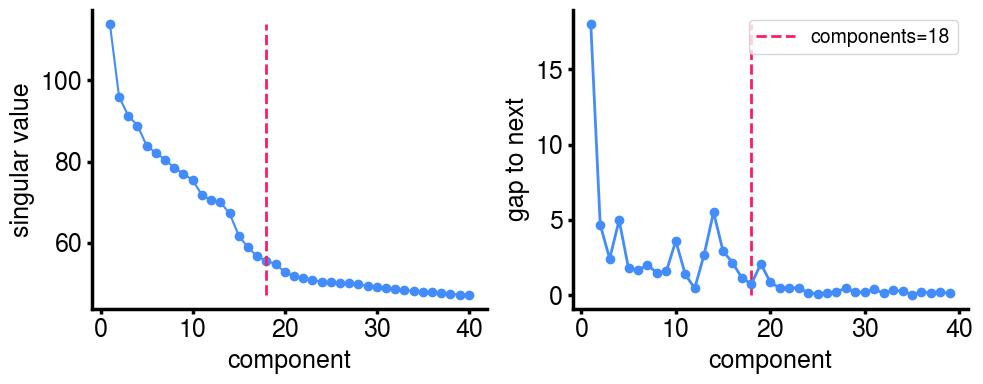

In [135]:
N_PROBE = 40
svd_probe = TruncatedSVD(n_components=N_PROBE, random_state=0).fit(X)
sv = svd_probe.singular_values_
 
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(np.arange(1, N_PROBE+1), sv, "o-", color = colors[2], linewidth=1.5)
ax[0].set_xlabel("component", size=18)
ax[0].set_ylabel("singular value", size=18)
# ax[0].set_title("scree", size=18)
ax[0].tick_params(labelsize=18)
ax[0].vlines(x=18, ymin=min(sv), ymax=max(sv), label='components=18', color=colors[0], linestyle='--', linewidth=2)
ax[1].vlines(x=18, ymin=0, ymax=max(sv[:-1] - sv[1:]), label='components=18', color=colors[0], linestyle='--', linewidth=2)
# ax[1].vlines(x=19, ymin=0, ymax=max(sv[:-1] - sv[1:]), label='K=19', color=colors[0], linestyle='--', linewidth=2)

ax[1].plot(np.arange(1, N_PROBE), sv[:-1] - sv[1:], "o-", color = colors[2], linewidth=2)
ax[1].set_xlabel("component", size=18)
ax[1].set_ylabel("gap to next", size=18)
# ax[1].set_title("consecutive gaps (last big gap ~ K)", size=18)
ax[1].tick_params(labelsize=18)

plt.legend(fontsize=14)

sns.despine(fig)

plt.tight_layout(); plt.show()

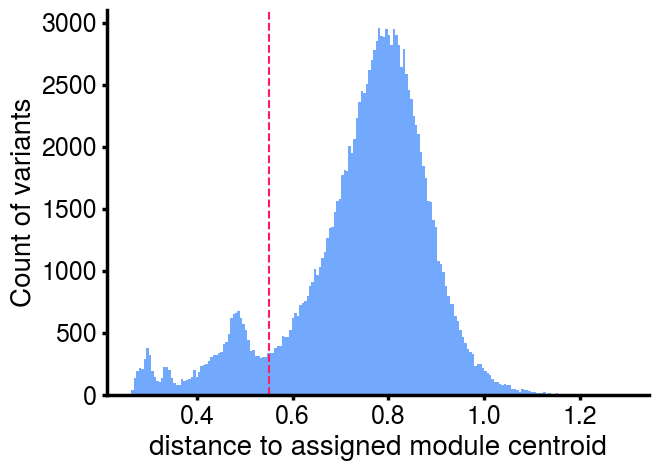

In [136]:
# distance of each variant to its own centroid -> how cleanly it belongs
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(d0, 
             alpha=0.75,
             color = colors[2],
             linewidth=0,
             ax=ax,
             # log_scale=True,
             bins=200
            )
# ax.set_yscale('log')
plt.xlabel("distance to assigned module centroid", fontsize=20)
plt.ylabel("Count of variants", fontsize=20)
ax.tick_params(labelsize=18)

# plt.hist(d_own, bins=200); plt.xlabel("distance to assigned module centroid")
plt.axvline(x=0.55, color=colors[0], linestyle='--', linewidth=1.5)

# plt.ylabel("variants"); plt.title("module membership confidence"); plt.show()

In [139]:
# --- 2. Refit on confidently co-varying sites (the "core") -----------------------------------------
N_CORE = (d0<0.55).sum()

core = np.sort(np.argsort(d0)[:min(N_CORE, len(d0))])   # confident core
X_core, core_idx = X[:, core], inf_idx[core]
 
vmod_core, d_core = _modules(X_core, N_COMP, K)         # refit on the core

m_core = DP[:, core_idx] >= MIN_DP_VAR

print(f"core {len(core_idx)} variants | median d {np.median(d_core):.3f} "
      f"(was {np.median(d0[core]):.3f} on the full panel) | "
      f"sites/cell {np.median(m_core.sum(1)):.0f} | "
      f"cells/variant {np.median(m_core.sum(0)):.0f}")

vmod_core, d_core = _modules(X_core, N_COMP, K)

core 15808 variants | median d 0.123 (was 0.462 on the full panel) | sites/cell 3470 | cells/variant 720


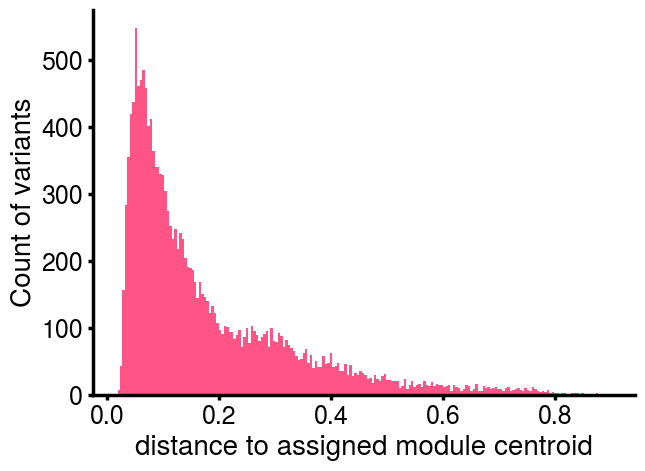

In [140]:
# distance of each variant to its own centroid -> how cleanly it belongs
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(d_core, 
             alpha=0.75,
             color = colors[0],
             linewidth=0,
             ax=ax,
             # log_scale=True,
             bins=200
            )
# ax.set_yscale('log')
plt.xlabel("distance to assigned module centroid", fontsize=20)
plt.ylabel("Count of variants", fontsize=20)
ax.tick_params(labelsize=18)

# plt.hist(d_own, bins=200); plt.xlabel("distance to assigned module centroid")
# plt.axvline(x=0.55, color=colors[0], linestyle='--', linewidth=1.5)

# plt.ylabel("variants"); plt.title("module membership confidence"); plt.show()

In [141]:
# --- 3. score every cell ----------------------------------------------------
W, _ = _score(core_idx, vmod_core)
use    = np.unique(vmod_core)
n_mod  = W.shape[1]                       # modules actually present
order  = np.argsort(-W, axis=1)
purity = W[np.arange(len(W)), order[:, 0]]
second = W[np.arange(len(W)), order[:, 1]]
donor     = use[order[:, 0]]
runner_up = use[order[:, 1]]
ratio     = second / np.maximum(purity, 1e-9)
eff       = 1.0 / np.sum(W**2, axis=1)    # ~1 clean cell, ~2 doublet, ~n_mod soup
n_core_sites = (DP[:, core_idx] >= MIN_DP_VAR).sum(1)

## Background Classification
# BG_RATIO  = 0.7
# BG_PURITY = 0.2
# background = (ratio > BG_RATIO) | (purity < BG_PURITY)
BG_PURITY = 0.4
background = purity < BG_PURITY

call = np.where(background, "background",
                np.array([f"worm{d:02d}" for d in donor]))

# --- 3. add to adata -------------------------------------------------------
adata.obs["donor"]        = pd.Categorical(call)
adata.obs["capsule_type"] = pd.Categorical(
    np.where(background, "background", "cell"),
    categories=["cell", "background"], ordered=True)
adata.obs["purity"]       = purity
adata.obs["alpha_hap"]    = 1 - purity
adata.obs["hap_ratio"]    = ratio
adata.obs["eff_modules"]  = eff
adata.obs["runner_up"]    = pd.Categorical([f"worm{d:02d}" for d in runner_up])
adata.obs["n_core_sites"] = n_core_sites

is_core = np.zeros(adata.n_vars, bool); is_core[core_idx] = True
module  = np.full(adata.n_vars, None, dtype=object)
module[core_idx] = [f"m{k:02d}" for k in vmod_core]
dist    = np.full(adata.n_vars, np.nan); dist[core_idx] = d_core
adata.var["is_core"]     = is_core
adata.var["module"]      = pd.Categorical(module)
adata.var["module_dist"] = dist

In [142]:
adata.obs.to_csv('../results/worm6_final/DNA_analysis/obs.csv')

### Worm Palette

In [143]:
worms = adata.obs['donor'].sort_values().unique().tolist()

pal = {worm:extended_colors[i] for i,worm in enumerate(worms)}


### UMAP of cells, based on SVD of their core sites

In [144]:
N_EMB=18
SEED=1

pos_core = np.searchsorted(inf_idx, core_idx)
emb  = TruncatedSVD(n_components=N_EMB, random_state=SEED).fit_transform(X[:, pos_core])
U    = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=SEED).fit_transform(emb)
nsit = (DP[:, core_idx] >= MIN_DP_VAR).sum(1)

# X[:,pos_core]

/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


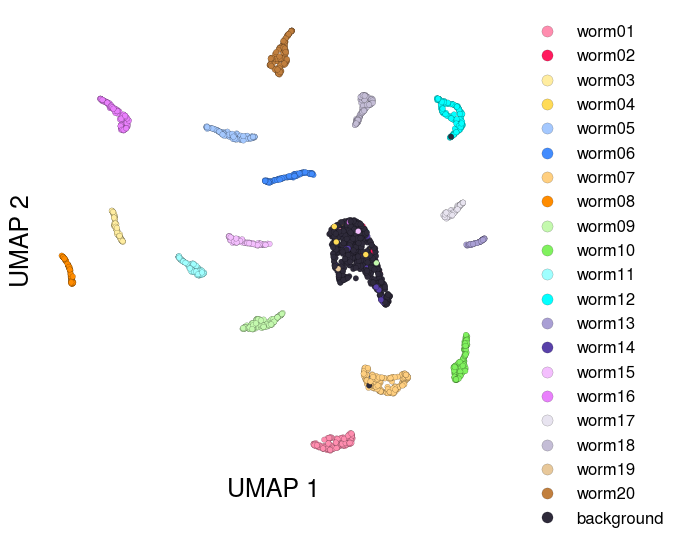

In [145]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sns.scatterplot(x=U[:,0], y=U[:,1], s=16, ax=ax, legend=True,
                hue=call, palette=pal,
                ec="black",
                linewidth=0.1,
                alpha=1, 
                hue_order=[f"worm{k:02d}" for k in np.unique(donor)] + ["background"])

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False,
             fontsize=12, markerscale=2)

# ax.set_title("Assignment", fontsize=18)

ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel("UMAP 1", fontsize=18); ax.set_ylabel("UMAP 2", fontsize=18)

sns.despine(fig, left=True, bottom=True)

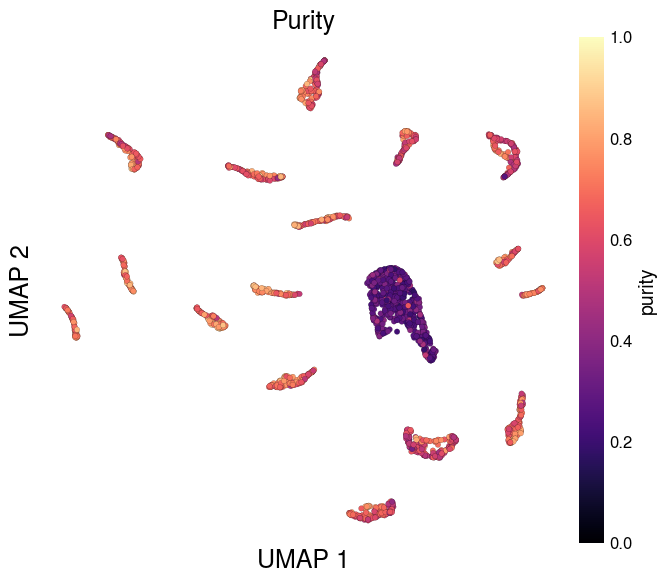

In [146]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sc = ax.scatter(U[:,0], U[:,1], s=16, c=purity, cmap="magma", vmin=0, vmax=1,
                ec="black", linewidth=0.1, alpha=1)
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("purity", fontsize=14)
cb.outline.set_visible(False)
cb.ax.tick_params(size=0, labelsize=12)

ax.set_title("Purity", fontsize=18)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("UMAP 1", fontsize=18); ax.set_ylabel("UMAP 2", fontsize=18)
sns.despine(fig, left=True, bottom=True)
plt.tight_layout(); plt.show()

### Cluster cells UPGMA

In [147]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

15808 core sites | 2404 cells
median shared core sites/pair: 970


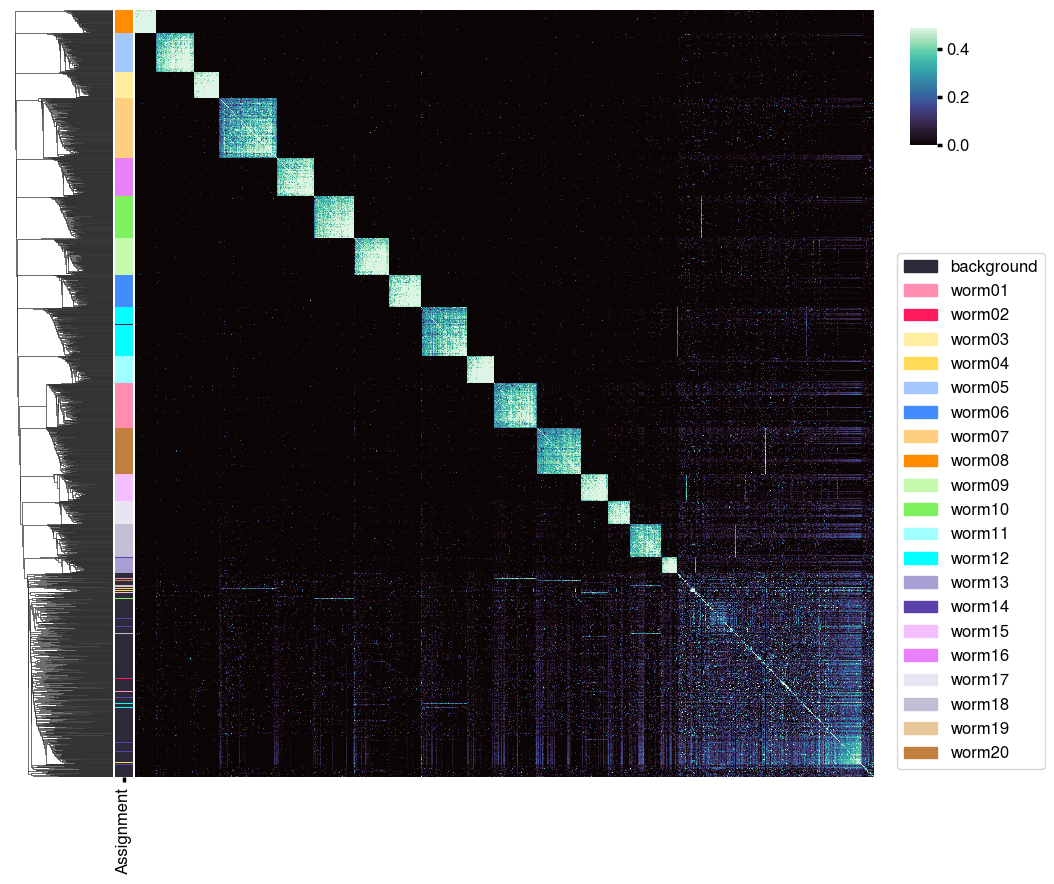

In [148]:
MIN_DP_VAR = 1
MIN_SHARED = 50          # zero the correlation below this many jointly-covered sites

# --- core sites straight from .var -----------------------------------------
core_idx = np.flatnonzero(adata.var["is_core"].values)
donor    = adata.obs["donor"].values
print(f"{len(core_idx)} core sites | {adata.n_obs} cells")

ad = adata.layers["AD"][:, core_idx].toarray().astype(np.float32)
dp = adata.layers["DP"][:, core_idx].toarray().astype(np.float32)
m  = dp >= MIN_DP_VAR
M  = m.astype(np.float32)

# --- masked correlation: only jointly-covered sites contribute --------------
with np.errstate(invalid="ignore", divide="ignore"):
    f = np.where(m, ad / np.maximum(dp, 1), np.nan)
X = np.where(m, f - np.nanmean(f, 0), 0.0).astype(np.float32)
n   = M @ M.T
den = np.sqrt((X * X) @ M.T * (M @ (X * X).T))
C = np.divide(X @ X.T, den, out=np.zeros_like(den), where=den > 0)
C[n < MIN_SHARED] = 0
C = np.clip(0.5 * (C + C.T), -1, 1).astype(np.float64); np.fill_diagonal(C, 1)
print(f"median shared core sites/pair: {np.median(n[~np.eye(len(n), dtype=bool)]):.0f}")

# --- UPGMA -----------------------------------------------------------------
D = 1 - C; np.fill_diagonal(D, 0)
D = np.clip(0.5 * (D + D.T), 0, None)          # squareform needs exact symmetry
Z = linkage(squareform(D, checks=False), "average")

# --- palette over ALL labels, including background  -------------
# pal = {w: extended_colors[i % len(extended_colors)] for i, w in enumerate(pd.unique(donor))}
idx = np.arange(len(C))
side = pd.DataFrame({"Assignment": [pal.get(d, "#FFFFFF") for d in donor]}, index=idx)

g = sns.clustermap(pd.DataFrame(C, index=idx, columns=idx),
                   row_linkage=Z, col_linkage=Z, cmap="mako",
                   vmin=0, vmax=np.percentile(C[C < 1], 99),
                   xticklabels=False, yticklabels=False,
                   row_colors=side, colors_ratio=0.02,
                   dendrogram_ratio=(0.12, 0.0), figsize=(9, 9),
                   cbar_pos=(0.02, 0.83, 0.03, 0.13))

g.ax_row_dendrogram.set_visible(True)
g.cax.set_position([1.02, 0.83, 0.03, 0.13]) 

handles = [mpl.patches.Patch(color=c, label=l) for l, c in pal.items()
           if l in set(donor)]
g.ax_heatmap.legend(handles=handles, bbox_to_anchor=(1.02, 0.0), loc="lower left",
                    fontsize=12, ncol=1)
plt.show()

### Purity

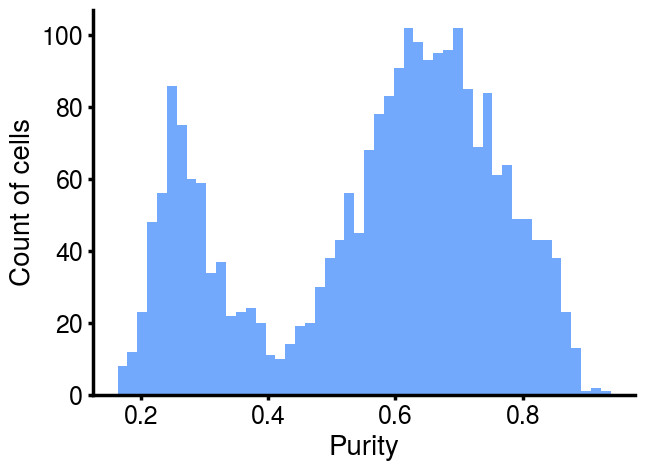

In [149]:
# distance of each variant to its own centroid -> how cleanly it belongs
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(purity, 
             alpha=0.75,
             color = colors[2],
             linewidth=0,
             ax=ax,
             # log_scale=True,
             bins=50
            )
# ax.set_yscale('log')
plt.xlabel("Purity", fontsize=20)
plt.ylabel("Count of cells", fontsize=20)
ax.tick_params(labelsize=18)

# plt.ylabel("variants"); plt.title("module membership confidence"); plt.show()

### Replot without background capsules

In [326]:
import anndata
adata = anndata.read_h5ad('../results/worm6_final/DNA_analysis/joint_variants_process.h5ad')

In [327]:
N_EMB = 18
SEED  = 1
drop  = ['worm02', 
         'worm04',
         'worm14', 
         'worm19']

donor_all  = adata.obs['donor'].values          # always full length
purity_all = adata.obs['purity'].values
keep = ~background & ~adata.obs['donor'].isin(drop).values
assert len(keep) == adata.n_obs, f"keep {len(keep)} vs {adata.n_obs}"
print(f"keeping {keep.sum()} of {adata.n_obs} "
      f"({(~keep).sum()} dropped: background + {drop})")

core_idx = np.flatnonzero(adata.var["is_core"].values)
a = adata.layers["AD"][:, core_idx].toarray()[keep].astype(np.float32)
d = adata.layers["DP"][:, core_idx].toarray()[keep].astype(np.float32)
m = d >= MIN_DP_VAR
with np.errstate(invalid="ignore", divide="ignore"):
    f = np.where(m, a / np.maximum(d, 1), np.nan)
Xk = np.where(m, f - np.nanmean(f, 0), 0.0).astype(np.float32)

emb  = TruncatedSVD(n_components=N_EMB, random_state=SEED).fit_transform(Xk)
U    = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=SEED).fit_transform(emb)
nsit = m.sum(1)

donor_k, purity_k = donor_all[keep], purity_all[keep]
print(f"{Xk.shape[0]} capsules x {Xk.shape[1]} core variants | "
      f"{len(pd.unique(donor_k))} worms shown")

keeping 1775 of 2404 (629 dropped: background + ['worm02', 'worm04', 'worm14', 'worm19'])


/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


1775 capsules x 15808 core variants | 16 worms shown


worm01    worm01
worm03    worm02
worm05    worm03
worm06    worm04
worm07    worm05
worm08    worm06
worm09    worm07
worm10    worm08
worm11    worm09
worm12    worm10
worm13    worm11
worm15    worm12
worm16    worm13
worm17    worm14
worm18    worm15
worm20    worm16


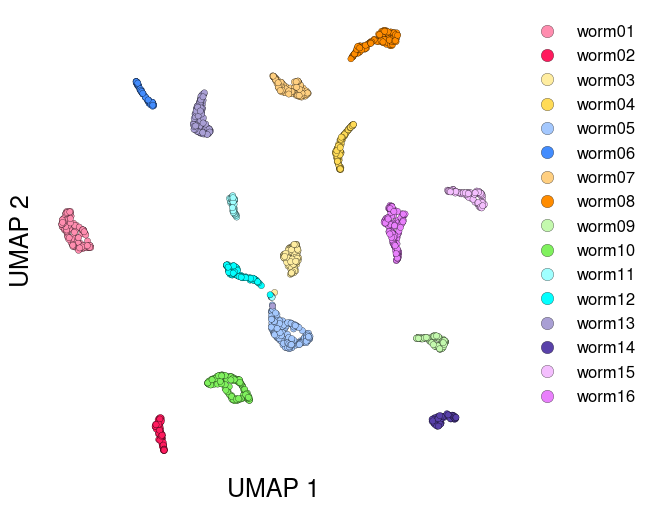

In [328]:
# map surviving worms to consecutive numbers, in their existing order
labels = donor_k                                   # from adata.obs, in sync with keep
present = [w for w in sorted(set(labels))]
worm_lbls = [w for w in present if w.startswith("worm")]
renum = {w: f"worm{i+1:02d}" for i, w in enumerate(worm_lbls)}
renum.update({w: w for w in present if not w.startswith("worm")})

cols  = extended_colors[1:]
pal_k = {renum[w]: cols[i % len(cols)] for i, w in enumerate(worm_lbls)}
pal_k.update({renum[w]: "#BFBFBF" for w in present if not w.startswith("worm")})

call_k = np.array([renum[l] for l in labels])      # note [l], not .get -- fails loudly
assert set(call_k) <= set(pal_k), f"unmapped: {set(call_k) - set(pal_k)}"
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sns.scatterplot(x=U[:,0], y=U[:,1], s=20, ax=ax, legend=True,
                hue=call_k, palette=pal_k,
                ec="black", linewidth=0.2, alpha=1,
                hue_order=list(pal_k.keys()))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False,
          fontsize=12, markerscale=2)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("UMAP 1", fontsize=18); ax.set_ylabel("UMAP 2", fontsize=18)
sns.despine(fig, left=True, bottom=True)

print(pd.Series(renum).to_string())   # keep the mapping!

fig.savefig('../results/worm6_final/figures/clean_ind_umap.png', dpi=600, bbox_inches='tight')

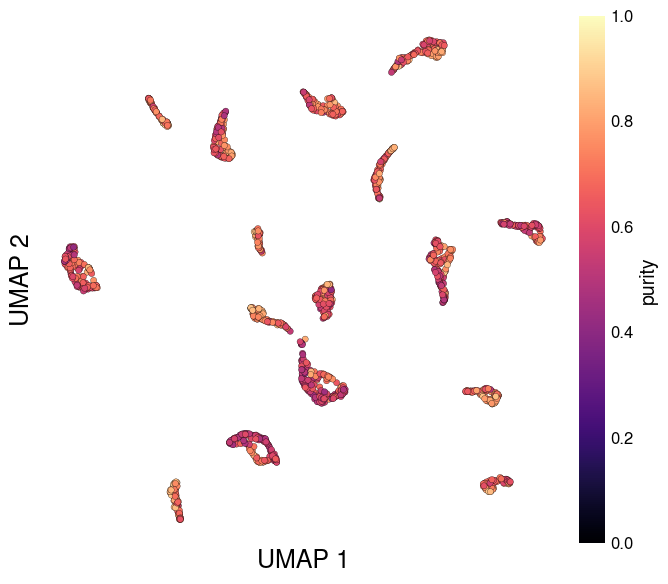

In [329]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sc = ax.scatter(U[:,0], U[:,1], s=20, c=purity[keep], cmap="magma", vmin=0, vmax=1,
                ec="black", linewidth=0.2, alpha=1)
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("purity", fontsize=14)
cb.outline.set_visible(False)
cb.ax.tick_params(size=0, labelsize=12)

# ax.set_title("Purity", fontsize=18)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("UMAP 1", fontsize=18); ax.set_ylabel("UMAP 2", fontsize=18)
sns.despine(fig, left=True, bottom=True)
plt.tight_layout(); plt.show()
fig.savefig('../results/worm6_final/figures/clean_ind_umap_pur.png', dpi=600, bbox_inches='tight')

15808 core sites | 1775 of 2404 cells (629 dropped: background + ['worm02', 'worm04', 'worm14', 'worm19'])
median shared core sites/pair: 1015
worm01    worm01
worm03    worm02
worm05    worm03
worm06    worm04
worm07    worm05
worm08    worm06
worm09    worm07
worm10    worm08
worm11    worm09
worm12    worm10
worm13    worm11
worm15    worm12
worm16    worm13
worm17    worm14
worm18    worm15
worm20    worm16


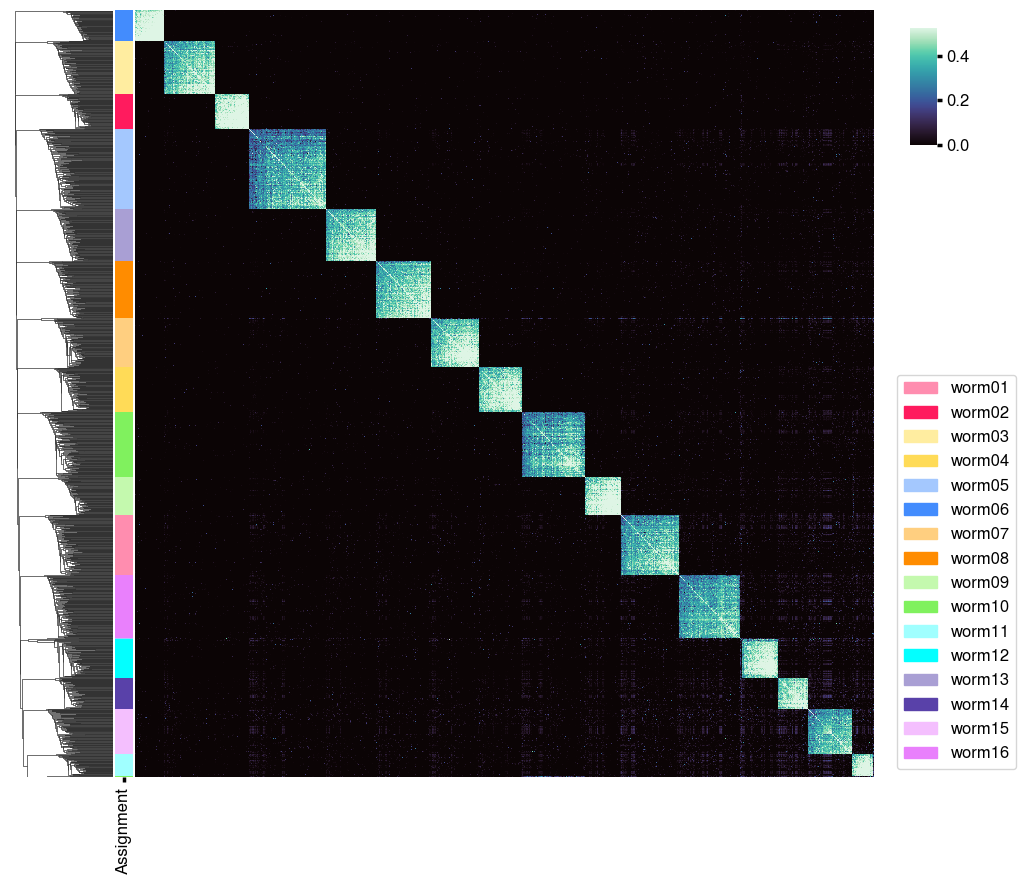

In [333]:
MIN_DP_VAR = 1
MIN_SHARED = 50          # zero the correlation below this many jointly-covered sites
DROP = ['worm02', 'worm04','worm14', 'worm19']

# --- cell filter, defined ONCE from adata (never from a subset variable) -----
core_idx  = np.flatnonzero(adata.var["is_core"].values)
donor_all = adata.obs["donor"].values
keep = (donor_all != "background") & ~adata.obs["donor"].isin(DROP).values
assert len(keep) == adata.n_obs
donor = donor_all[keep]
print(f"{len(core_idx)} core sites | {keep.sum()} of {adata.n_obs} cells "
      f"({(~keep).sum()} dropped: background + {DROP})")

ad = adata.layers["AD"][:, core_idx].toarray()[keep].astype(np.float32)
dp = adata.layers["DP"][:, core_idx].toarray()[keep].astype(np.float32)
m  = dp >= MIN_DP_VAR
M  = m.astype(np.float32)

# --- masked correlation: only jointly-covered sites contribute --------------
with np.errstate(invalid="ignore", divide="ignore"):
    f = np.where(m, ad / np.maximum(dp, 1), np.nan)
X = np.where(m, f - np.nanmean(f, 0), 0.0).astype(np.float32)   # recentred on survivors
n   = M @ M.T
den = np.sqrt((X * X) @ M.T * (M @ (X * X).T))
C = np.divide(X @ X.T, den, out=np.zeros_like(den), where=den > 0)
C[n < MIN_SHARED] = 0
C = np.clip(0.5 * (C + C.T), -1, 1).astype(np.float64); np.fill_diagonal(C, 1)
print(f"median shared core sites/pair: {np.median(n[~np.eye(len(n), dtype=bool)]):.0f}")

# --- UPGMA -----------------------------------------------------------------
D = 1 - C; np.fill_diagonal(D, 0)
D = np.clip(0.5 * (D + D.T), 0, None)
Z = linkage(squareform(D, checks=False), "average")

# --- palette + renumbering over the surviving labels ------------------------
worms  = sorted(pd.unique(donor))
renum  = {w: f"worm{i+1:02d}" for i, w in enumerate(worms)}
cols   = extended_colors[1:]                       # skip the first colour
pal    = {renum[w]: cols[i % len(cols)] for i, w in enumerate(worms)}
donor_r = np.array([renum[d] for d in donor])
print(pd.Series(renum).to_string())                # keep this mapping

assert len(donor_r) == len(C), f"donor {len(donor_r)} vs C {len(C)}"
idx  = np.arange(len(C))
side = pd.DataFrame({"Assignment": [pal[d] for d in donor_r]}, index=idx)

g = sns.clustermap(pd.DataFrame(C, index=idx, columns=idx),
                   row_linkage=Z, col_linkage=Z, cmap="mako",
                   vmin=0, vmax=np.percentile(C[C < 1], 99),
                   xticklabels=False, yticklabels=False,
                   row_colors=side, colors_ratio=0.02,
                   dendrogram_ratio=(0.12, 0.0), figsize=(9, 9),
                   cbar_pos=(0.02, 0.83, 0.03, 0.13))
g.ax_row_dendrogram.set_visible(True)
g.cax.set_position([1.02, 0.83, 0.03, 0.13])
handles = [mpl.patches.Patch(color=pal[renum[w]], label=renum[w]) for w in worms]
g.ax_heatmap.legend(handles=handles, bbox_to_anchor=(1.02, 0.0), loc="lower left",
                    fontsize=12, ncol=1)
plt.show()
g.savefig('../results/worm6_final/figures/clean_ind_hm.png', dpi=600, bbox_inches='tight')

## Save anndata

In [259]:
adata.write_h5ad('../results/worm6_final/DNA_analysis/joint_variants_process.h5ad')